In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [2]:
(input_train,label_train), (input_test,label_test) = cifar10.load_data()
print(input_test.shape)
print(label_test.shape)


(10000, 32, 32, 3)
(10000, 1)


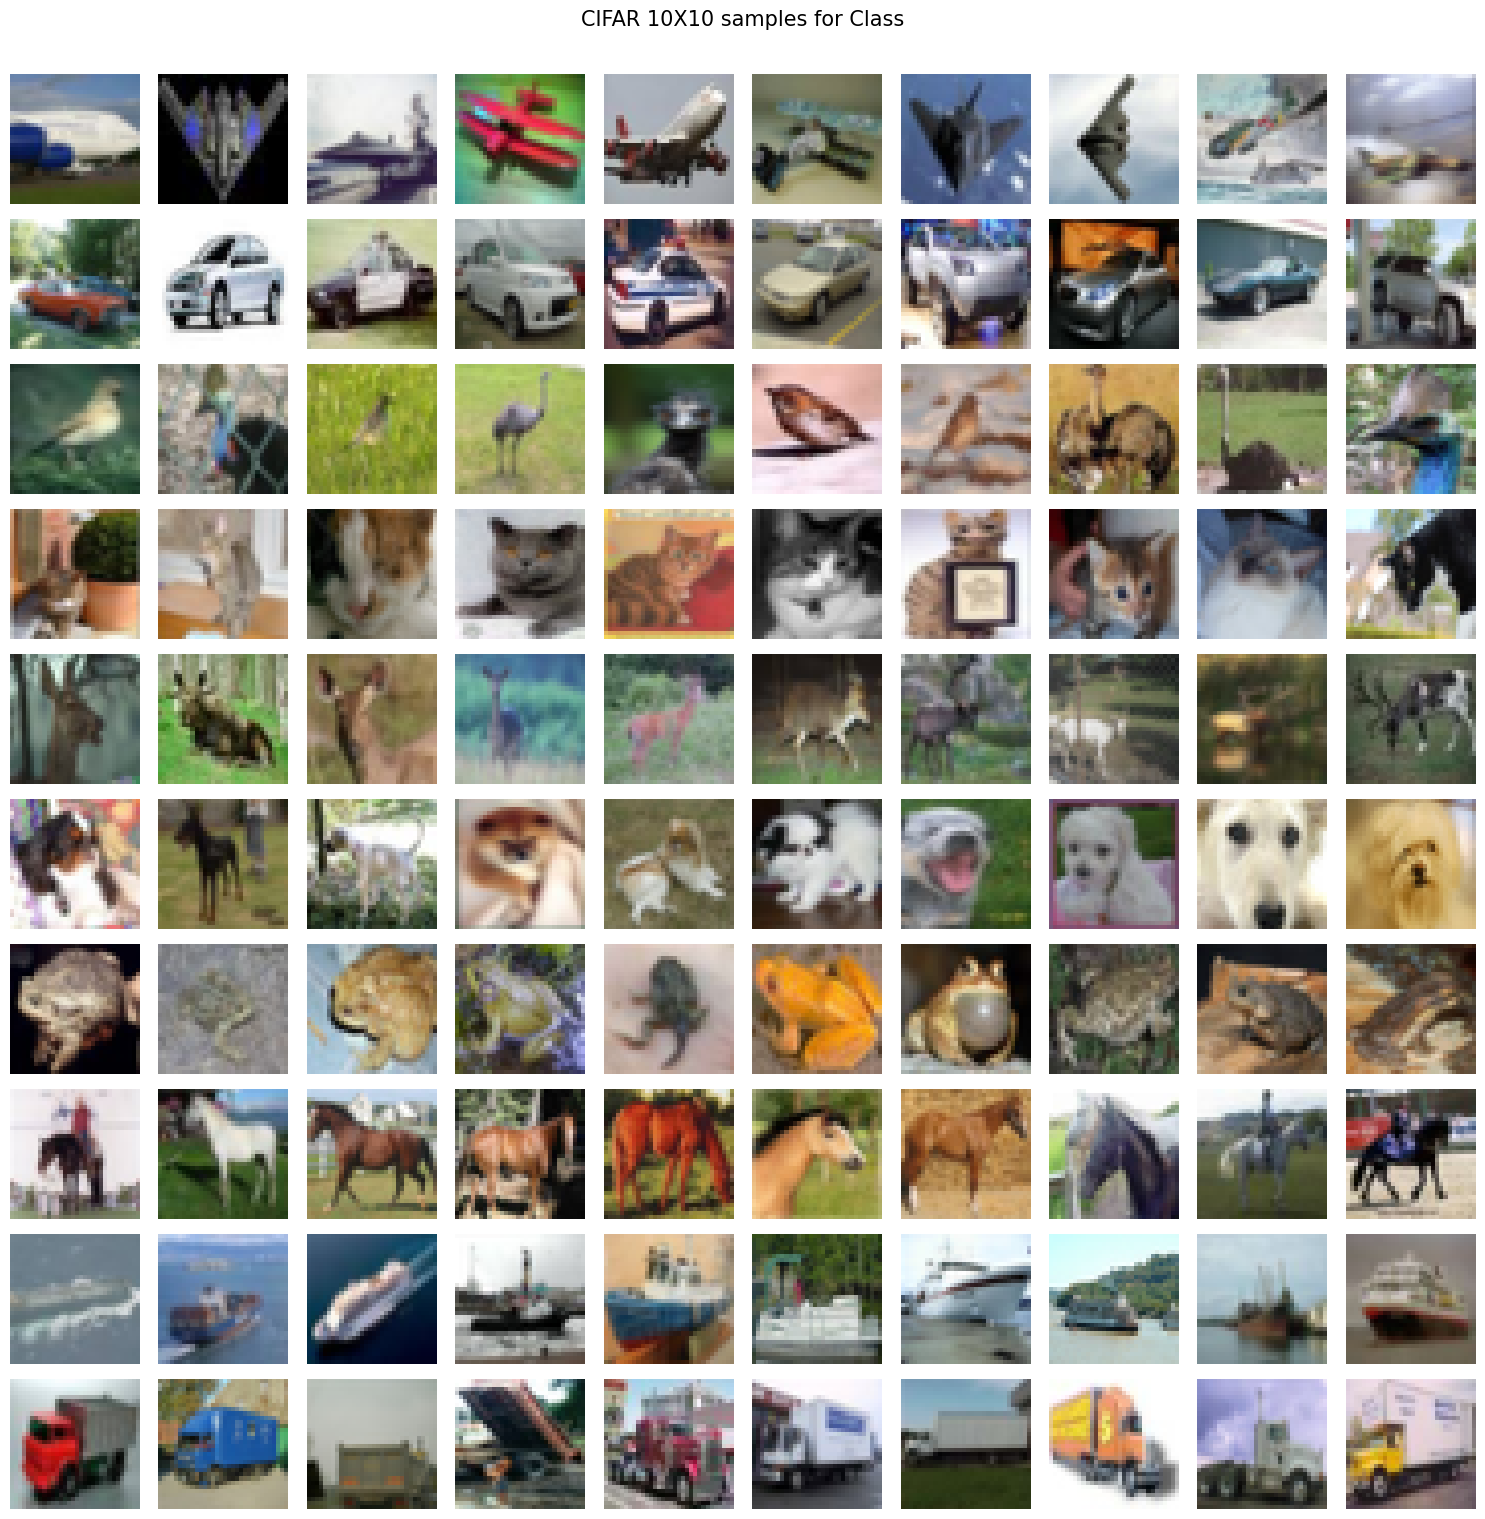

In [3]:
class_names = ['airplane', 'automoblie', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(10,10, figsize=(15,15))
fig.suptitle('CIFAR 10X10 samples for Class', fontsize=15, y=1.01)

for class_idx in range(10):
    index=np.where(label_test.flatten()== class_idx)[0]
    samples = np.random.choice(index, 10, replace=False)
    for col, sample_idx in enumerate(samples):
        ax=axes[class_idx, col]
        ax.imshow(input_test[sample_idx])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=9, rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.show()

In [4]:
from preProc import one_hot_encode, normalize

# print(f'label_train Shape before OHE:{label_train.shape}')
# print(f'label_test Shape before OHE:{label_test.shape}{'\n'}')
# label_train = one_hot_encode(label_train)
# label_test = one_hot_encode(label_test)
# print(f'label_train Shape after OHE:{label_train.shape}')
# print(f'label_test Shape after OHE:{label_test.shape}{'\n'}')

print(f'input_train Max & Min pixel value before normalize:{input_train.max()},{input_train.min()}')
print(f'input_test Max & Min pixel value before normalize:{input_test.max()}, {input_test.min()}{'\n'}')
input_train = normalize(input_train)
input_test = normalize(input_test)
print(f'input_train Max & Min pixel value after normalize:{input_train.max()},{input_train.min()}')
print(f'input_test Max & Min pixel value after normalize:{input_test.max()}, {input_test.min()}{'\n'}')


input_train Max & Min pixel value before normalize:255,0
input_test Max & Min pixel value before normalize:255, 0

input_train Max & Min pixel value after normalize:1.0,0.0
input_test Max & Min pixel value after normalize:1.0, 0.0



In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD

model1 = Sequential([
    # --- Block 1 ---
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),   # 32x32 → 16x16

    # --- Block 2 ---
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),   # 16x16 → 8x8

    # --- Block 3 ---
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),   # 8x8 → 4x4

    # --- Classifier head ---
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

model1.summary()

c:\Users\charl\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,158 (1.14 MB)

 Trainable params: 299,158 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    input_train, label_train,
    test_size=0.1,
    random_state=42,
    stratify=label_train
)

print(f'X Train Shape:{X_train.shape} {'\n'}X test shape:{X_test.shape}')
print(f'y Train Shape:{y_train.shape} {'\n'}y test shape:{y_test.shape}')

# print(X_train[0:5])
# print(y_train[0:5])



X Train Shape:(45000, 32, 32, 3) 
X test shape:(5000, 32, 32, 3)
y Train Shape:(45000, 1) 
y test shape:(5000, 1)


In [9]:
from tensorflow.keras.optimizers import Adam

# model1.compile(
#     optimizer='sgd',
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainer = model1.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.4466 - loss: 1.5238 - val_accuracy: 0.5582 - val_loss: 1.2421
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6162 - loss: 1.0842 - val_accuracy: 0.6430 - val_loss: 1.0334
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6831 - loss: 0.9108 - val_accuracy: 0.6796 - val_loss: 0.9363
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.7225 - loss: 0.7968 - val_accuracy: 0.7128 - val_loss: 0.8288
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7522 - loss: 0.7115 - val_accuracy: 0.7168 - val_loss: 0.8214
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7776 - loss: 0.6414 - val_accuracy: 0.7134 - val_loss: 0.8251
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7985 - loss: 0.5771 - val_accuracy: 0.7392 - val_loss: 0.7753
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8214 - loss: 0.5133 - 

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred=model1.predict(X_test)
y_pred=np.argmax(y_pred, axis=1)

print(y_pred[0:5])

val_loss, val_acc = model1.evaluate(X_test, y_test, verbose=0)

train_acc = trainer.history['accuracy']
train_loss= trainer.history['loss']

print(f"Validation Loss:     {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)\n")
print(f"Final Training Loss:       {train_loss[-1]:.4f}")
print(f"Final Training Accuracy:   {train_acc[-1]:.4f} ({train_acc[-1]*100:.2f}%)\n")


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
[7 2 7 9 2]
Validation Loss:     0.8304
Validation Accuracy: 0.7406 (74.06%)

Final Training Loss:       0.4084
Final Training Accuracy:   0.8559 (85.59%)



In [13]:
print(classification_report(y_test, y_pred, target_names=class_names))


              precision    recall  f1-score   support

    airplane       0.74      0.77      0.76       500
  automoblie       0.90      0.81      0.85       500
        bird       0.68      0.64      0.66       500
         cat       0.53      0.60      0.56       500
        deer       0.80      0.66      0.73       500
         dog       0.59      0.72      0.65       500
        frog       0.87      0.69      0.77       500
       horse       0.81      0.77      0.79       500
        ship       0.78      0.89      0.84       500
       truck       0.80      0.84      0.82       500

    accuracy                           0.74      5000
   macro avg       0.75      0.74      0.74      5000
weighted avg       0.75      0.74      0.74      5000



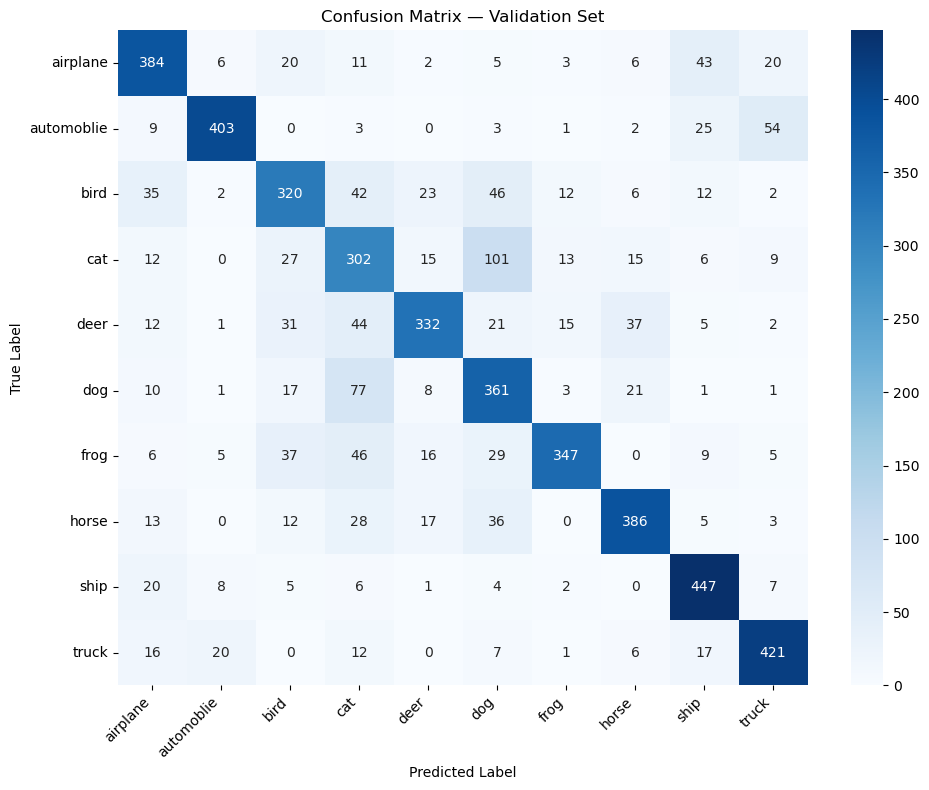

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()